# --- Data Preparation Orchestrator ---
<p>Data Orchectration script to perform data loading, exploratory analysis, preprocessing, & image augmentation</p>

In [1]:
# ==================
# Libraries
# ==================
import os
import sys
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy
import pandas
import random
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [ ]:
# =============================
# Create Workspace directory
# =============================
BASE_DIR = Path("/teamspace/studios/this_studio/aiport-incident-detection-final")
RAW_DIR = BASE_DIR / "data" / "raw"
PROC_DIR = BASE_DIR / "data" / "processed"

# Connect to custom-defined modules
sys.path.append(str(Path(os.getcwd()).parent))

# Create directory to store raw & processed data
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

# Auto-reload scripts if any changes
%reload_ext autoreload
%autoreload 2

print("Workspace successfully configured.")

Workspace successfully configured.


In [3]:
# =========================
# Import custom Modules
# =========================
from src.data.extractor import KaggleDatasetExtractor
from src.data.analyzer import MultiTaskDatasetAnalyzer

SyntaxError: invalid syntax (analyzer.py, line 3)

## Step 1: Data Extraction
1. Extract Stream datasets from Kaggle repository.
2. Perform initial analysis on the Raw datasets.

In [4]:
# ===========================
# Extract Stream datasets
# ===========================
# extractor = KaggleDatasetExtractor(download_root=RAW_DIR)
# extractor.download_all()
# extractor.reconstruct_all()

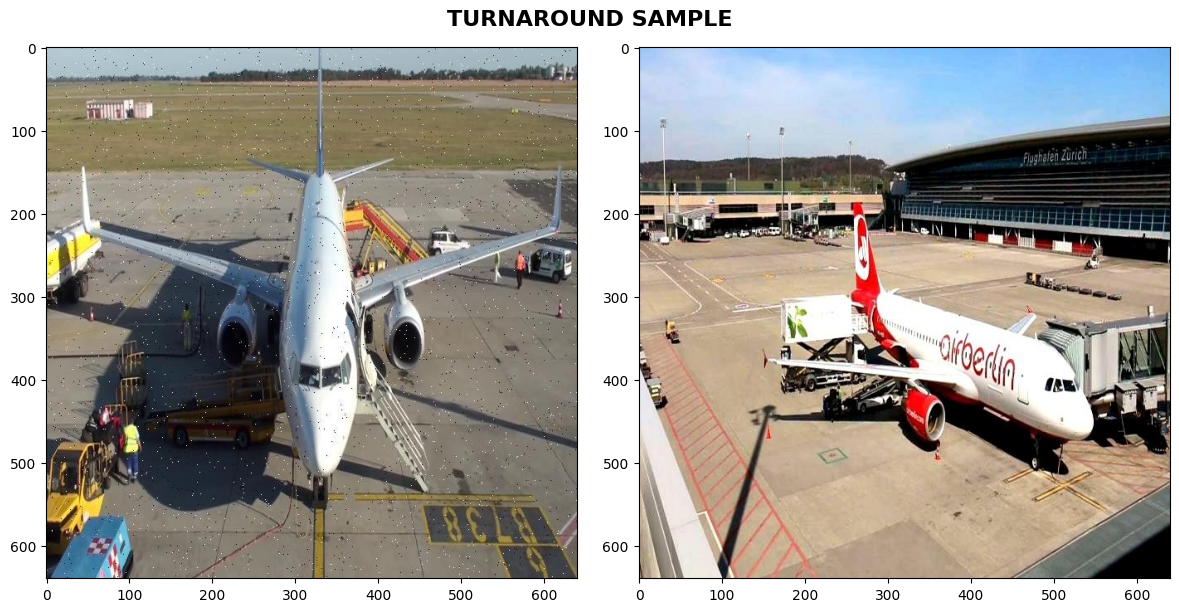

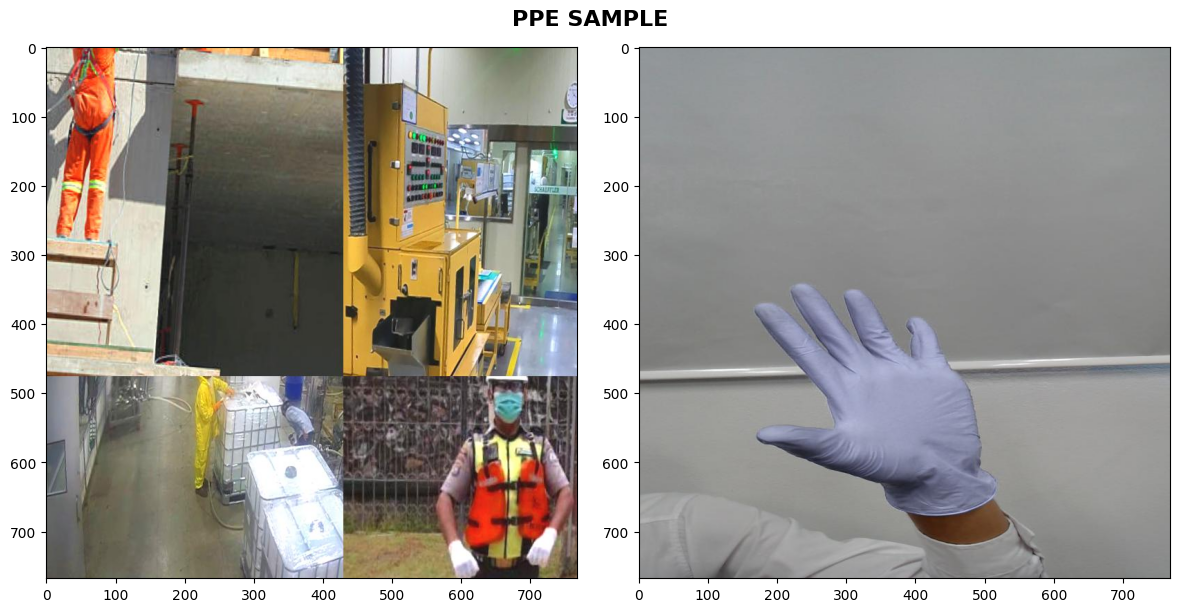

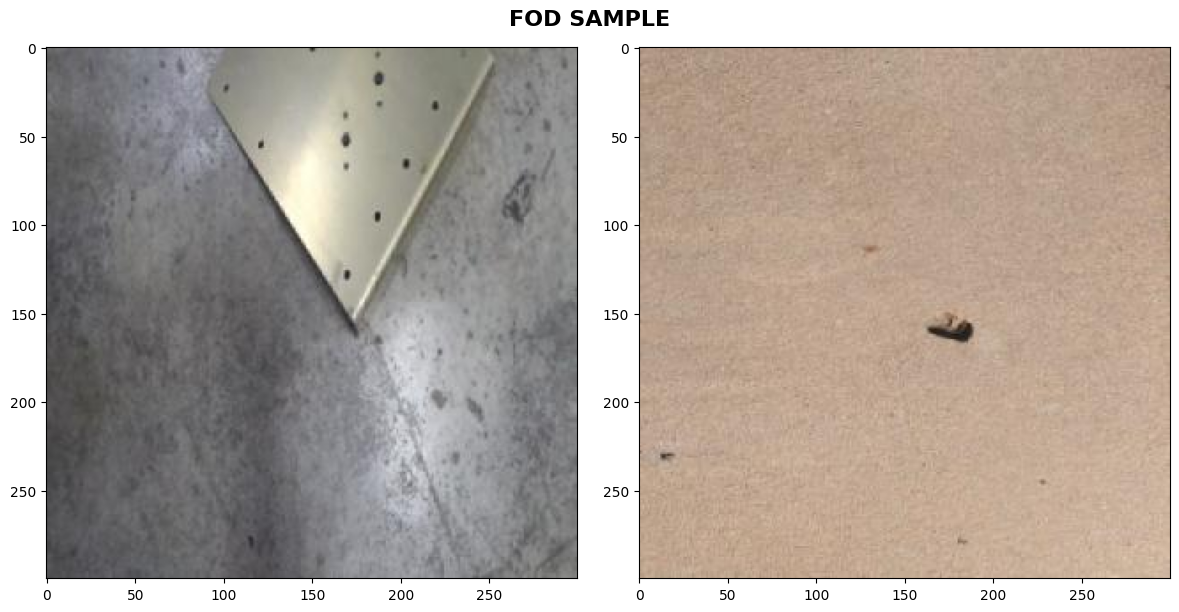

In [10]:
# ============================
# Sample Images of the Stream
# ============================
for task in ["turnaround", "ppe", "fod"]:
    folder_path = os.path.join(RAW_DIR, task, "images")
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    selected = random.sample(images, min(len(images), 2))
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for i, img_name in enumerate(selected):
        img = cv2.imread(os.path.join(folder_path, img_name))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    plt.suptitle(f"{task.upper()} SAMPLE", fontweight="bold", fontsize=16)
    plt.tight_layout()
    plt.show()

In [5]:
# =================================
# Initial Analysis on Raw dataset
# =================================
analyzer = MultiTaskDatasetAnalyzer(raw_root=RAW_DIR)
eda_results = analyzer.run_initial_eda()

# Render findings cleanly
for task, metrics in eda_results.items():
    print(f"\n==== 📊 Initial Profile for Task: {task.upper()} ====")
    print(f"• Image Count      : {metrics['total_images']}")
    print(f"• Label File Count : {metrics['total_label_files']}")
    print(f"• Class Frequencies: {metrics['raw_class_frequencies']}")
    if metrics['mismatch_warning']:
        print("⚠️ Warning: File count mismatch detected between image arrays and annotations.")


==== 📊 Initial Profile for Task: TURNAROUND ====
• Image Count      : 9740
• Label File Count : 9740
• Class Frequencies: {0: 6346, 1: 2316, 2: 1870, 3: 1793, 4: 956, 5: 4151, 6: 2539, 7: 2071, 8: 21977, 9: 2303, 10: 2964, 11: 4463, 12: 2729}

==== 📊 Initial Profile for Task: PPE ====
• Image Count      : 13140
• Label File Count : 13140
• Class Frequencies: {0: 5876, 1: 9836, 2: 6387, 3: 17402, 4: 16939, 5: 5071, 6: 6522, 7: 10955, 8: 13420, 9: 6871, 10: 8066, 11: 6848, 12: 11800, 13: 6392, 14: 11782, 15: 9340, 16: 6903, 17: 11917}

==== 📊 Initial Profile for Task: FOD ====
• Image Count      : 33793
• Label File Count : 0
• Class Frequencies: {}
⚠️ Warning: File count mismatch detected between image arrays and annotations.


<b>Challenges:</b>
1. <b>Turnaround severly lacks people:</b> It contains <i>person</i> class (class 7), but with only 2071 instances across 9,740 images, it will cause the model to be trained to ignore human ground staff.

2. <b>PPE is cluttered with unwanted classes:</b> It has 18 active classes, meaning it contains unneeded labels that will cause cross-task gradient conflicts in custom loss function.

3. <b>FOD is completely silent:</b> Becuase it is in Pascal-VOC (.xml) format. The parser completely ignored it.


## Step 2: Data Preprocessing
1. Convert FOD-A stream dataset to YOLO format.
2. Perform Exploratory Data Analysis
3. Perform Data preprocessing on all datasets.